# Artificial Intelligence Technology and Application

## Machine Learning Lab Guide - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 Flower Category Analysis

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 Iris Dataset
The built-in dataset avoids network downloads while preserving the flower classification task.


In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, stratify=iris.target, random_state=23)
scaler = StandardScaler().fit(X_train)
print(iris.target_names)


['setosa' 'versicolor' 'virginica']


## 1.2 Classifier Comparison
Several classical classifiers are evaluated with the same train/test split.


In [2]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

candidates = {
    "knn": KNeighborsClassifier(n_neighbors=5),
    "svm": SVC(kernel="rbf", gamma="scale"),
    "tree": DecisionTreeClassifier(max_depth=3, random_state=23),
    "logistic": LogisticRegression(max_iter=500),
}
for name, estimator in candidates.items():
    estimator.fit(scaler.transform(X_train), y_train)
    print(name, round(accuracy_score(y_test, estimator.predict(scaler.transform(X_test))), 3))


knn 0.974
svm 0.947
tree 0.921
logistic 0.947


## 1.3 Text Classification Extension
A small text sample demonstrates bag-of-words sentiment classification.


In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

texts = ["fresh flower bright", "large petal bright", "dry stem weak", "wilted flower weak"]
text_labels = [1, 1, 0, 0]
counts = CountVectorizer().fit_transform(texts)
tfidf = TfidfTransformer().fit_transform(counts)
nb = MultinomialNB().fit(tfidf, text_labels)
print(nb.predict(TfidfTransformer().fit_transform(CountVectorizer().fit(texts).transform(["bright fresh petal"]))))


[1]


## 1.4 Two-Feature Plot
Sepal features are visualized to inspect class separation.


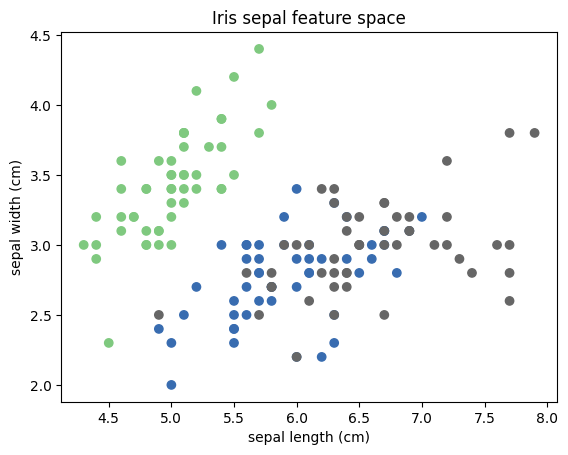

In [4]:
import matplotlib.pyplot as plt

plt.scatter(iris.data[:, 0], iris.data[:, 1], c=iris.target, cmap="Accent")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Iris sepal feature space")
plt.show()
